In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, cohen_kappa_score
from scipy.stats import pearsonr

from gensim.models import Word2Vec
from transformers import get_linear_schedule_with_warmup

from tqdm import tqdm

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
EPOCHS = 10
PATIENCE = 3
LEARNING_RATE = 1e-3
MAX_LENGTH = 384
RANDOM_SEED = 42
WARMUP_RATIO = 0.1

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Device:", DEVICE)

Device: cuda


In [3]:
df = pd.read_csv(
    "task1_cleaned_final.csv",
    engine="python",
    on_bad_lines="skip"
)

criteria_cols = [
    "Task_Achievement",
    "Coherence_Cohesion",
    "Lexical_Resource",
    "Range_Accuracy"
]

features = [
    "word_count",
    "unique_words",
    "ttr",
    "avg_word_len",
    "sentence_count",
    "avg_sentence_len",
    "sentence_len_var",
    "long_word_ratio",
    "short_word_ratio",
    "punct_density",
]

df = df.dropna(subset=criteria_cols + ["Essay"]).reset_index(drop=True)

print("Total essays:", len(df))

Total essays: 8327


In [4]:
df[criteria_cols] = df[criteria_cols] / 9.0

y = df[criteria_cols].values

X = [text.split() for text in df["Essay"]]

feat_values = df[features].values

In [5]:
idx = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    idx,
    test_size=0.3,
    random_state=RANDOM_SEED,
    shuffle=True
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=2/3,
    random_state=RANDOM_SEED
)

X_train = [X[i] for i in train_idx]
X_val   = [X[i] for i in val_idx]
X_test  = [X[i] for i in test_idx]

y_train = y[train_idx]
y_val   = y[val_idx]
y_test  = y[test_idx]

feat_train = feat_values[train_idx]
feat_val   = feat_values[val_idx]
feat_test  = feat_values[test_idx]

print(len(train_idx), len(val_idx), len(test_idx))

5828 833 1666


In [6]:
windows = [3, 5, 8]

best_score = float("inf")
best_window = None
best_w2v = None

for w in windows:

    print(f"\n========== WINDOW = {w} ==========")

    w2v = Word2Vec(
        sentences=X_train,
        vector_size=300,
        window=w,
        min_count=1,
        workers=4,
        sg=1,
        seed=RANDOM_SEED
    )

    X_train_vec = []
    for tokens in X_train:
        vecs = [w2v.wv[t] for t in tokens if t in w2v.wv]
        if len(vecs) == 0:
            X_train_vec.append(np.zeros(300))
        else:
            X_train_vec.append(np.mean(vecs, axis=0))

    X_val_vec = []
    for tokens in X_val:
        vecs = [w2v.wv[t] for t in tokens if t in w2v.wv]
        if len(vecs) == 0:
            X_val_vec.append(np.zeros(300))
        else:
            X_val_vec.append(np.mean(vecs, axis=0))

    X_train_vec = np.vstack(X_train_vec)
    X_val_vec   = np.vstack(X_val_vec)

    X_train_full = np.hstack([X_train_vec, feat_train])
    X_val_full   = np.hstack([X_val_vec, feat_val])

    scaler_tmp = StandardScaler()
    X_train_scaled = scaler_tmp.fit_transform(X_train_full)
    X_val_scaled   = scaler_tmp.transform(X_val_full)

    score = np.mean(np.abs(X_val_scaled))

    print("Proxy score:", score)

    if score < best_score:
        best_score = score
        best_window = w
        best_w2v = w2v

print("\nBest window:", best_window)


========== WINDOW = 3 ==========
Proxy score: 0.7856861188339783

========== WINDOW = 5 ==========
Proxy score: 0.7753955931647489

========== WINDOW = 8 ==========
Proxy score: 0.7653934246979254

Best window: 8


In [7]:
word2idx = {word: i+1 for i, word in enumerate(best_w2v.wv.index_to_key)}
word2idx["<PAD>"] = 0

vocab_size = len(word2idx)

embedding_matrix = np.zeros((vocab_size, 300))

for word, i in word2idx.items():
    if word in best_w2v.wv:
        embedding_matrix[i] = best_w2v.wv[word]

In [8]:
encoded = []

for text in df["Essay"]:
    tokens = text.split()
    ids = []

    for w in tokens:
        ids.append(word2idx.get(w, 0))

    if len(ids) > MAX_LENGTH:
        ids = ids[:MAX_LENGTH]
    else:
        ids = ids + [0] * (MAX_LENGTH - len(ids))

    encoded.append(ids)

input_ids = torch.tensor(np.array(encoded), dtype=torch.long)

In [9]:
scaler_feat = StandardScaler()

feat_train = scaler_feat.fit_transform(feat_train)
feat_val   = scaler_feat.transform(feat_val)
feat_test  = scaler_feat.transform(feat_test)

In [10]:
train_dataset = TensorDataset(
    input_ids[train_idx],
    torch.tensor(y_train, dtype=torch.float32),
    torch.tensor(feat_train, dtype=torch.float32)
)

val_dataset = TensorDataset(
    input_ids[val_idx],
    torch.tensor(y_val, dtype=torch.float32),
    torch.tensor(feat_val, dtype=torch.float32)
)

test_dataset = TensorDataset(
    input_ids[test_idx],
    torch.tensor(y_test, dtype=torch.float32),
    torch.tensor(feat_test, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [11]:
class BiLSTMAttentionIELTS(nn.Module):

    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False
        )

        self.lstm = nn.LSTM(
            input_size=300,
            hidden_size=256,
            batch_first=True,
            bidirectional=True,
            num_layers=2,
            dropout=0.3
        )

        self.attention = nn.Linear(512, 1)

        feature_dim = len(features)

        # FEATURE ATTENTION
        self.feature_attention = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.Tanh(),
            nn.Linear(feature_dim, feature_dim),
            nn.Softmax(dim=1)
        )

        self.feature_proj = nn.Linear(feature_dim, 64)

        self.fc = nn.Sequential(
            nn.Linear(512 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 4)
        )

    def forward(self, x, feats):

        x = self.embedding(x)

        lstm_out, _ = self.lstm(x)

        attn_scores = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)

        context = torch.sum(attn_weights * lstm_out, dim=1)

        # FEATURE ATTENTION
        feat_weights = self.feature_attention(feats)
        feats = feats * feat_weights

        feats = self.feature_proj(feats)

        x = torch.cat([context, feats], dim=1)

        out = torch.sigmoid(self.fc(x)) * 0.95 + 0.025

        return out

In [12]:
model = BiLSTMAttentionIELTS().to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

criterion = nn.MSELoss()

In [13]:
best_val = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
logs = []

In [14]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0

    for ids, crit, feat_batch in tqdm(train_loader):

        ids = ids.to(DEVICE)
        crit = crit.to(DEVICE)
        feat_batch = feat_batch.to(DEVICE)
        
        feat_noise = feat_batch + torch.randn_like(feat_batch) * 0.01


        optimizer.zero_grad()

        pred = model(ids, feat_noise)

        loss = criterion(pred, crit)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for ids, crit, feat_batch in val_loader:

            ids = ids.to(DEVICE)
            crit = crit.to(DEVICE)
            feat_batch  = feat_batch.to(DEVICE)

            pred = model(ids, feat_batch)

            loss = criterion(pred, crit)

            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)

    print("Train Loss:", avg_train)
    print("Val Loss:", avg_val)

    logs.append({
        "epoch": epoch + 1,
        "train_loss": avg_train,
        "val_loss": avg_val
    })

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    if avg_val < best_val:
        best_val = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), "bilstm_final.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break


Epoch 1/10


100%|██████████| 183/183 [00:12<00:00, 14.69it/s]


Train Loss: 0.02395482291340258
Val Loss: 0.017331899937104295

Epoch 2/10


100%|██████████| 183/183 [00:11<00:00, 15.66it/s]


Train Loss: 0.013253405700371566
Val Loss: 0.014326554309162829

Epoch 3/10


...

Train Loss: 0.0030221447884232378
Val Loss: 0.012578467976439882

Epoch 9/10


100%|██████████| 183/183 [00:11<00:00, 15.69it/s]


Train Loss: 0.0029147427085064394
Val Loss: 0.013077572471013776

Epoch 10/10


100%|██████████| 183/183 [00:11<00:00, 15.83it/s]


Train Loss: 0.0027181819021508424
Val Loss: 0.012960516485489078


In [15]:
log_df = pd.DataFrame(logs)

log_df.to_csv(
    "bilstm.csv",
    index=False
)

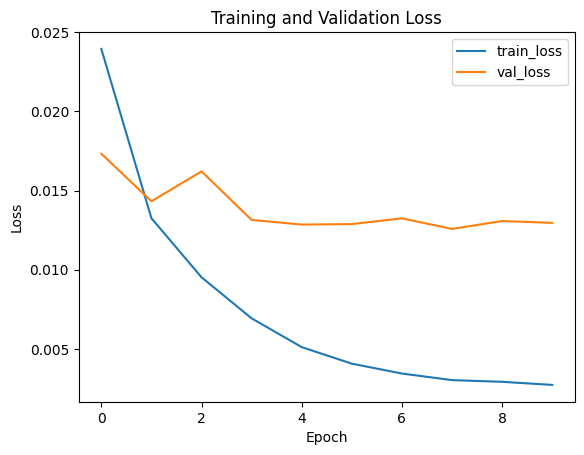

In [16]:
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [17]:
model.load_state_dict(torch.load("bilstm_final.pt"))
model.eval()

BiLSTMAttentionIELTS(
  (embedding): Embedding(35317, 300)
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (feature_attention): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): Tanh()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): Softmax(dim=1)
  )
  (feature_proj): Linear(in_features=10, out_features=64, bias=True)
  (fc): Sequential(
    (0): Linear(in_features=576, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=4, bias=True)
  )
)

In [18]:
preds = []
trues = []

with torch.no_grad():
    for ids, crit, feat_batch in test_loader:

        ids = ids.to(DEVICE)
        feat_batch = feat_batch.to(DEVICE)

        pred = model(ids, feat_batch)

        preds.append(pred.cpu().numpy())
        trues.append(crit.numpy())

pred = np.concatenate(preds) * 9
true = np.concatenate(trues) * 9

pred_overall = pred.mean(axis=1)
true_overall = true.mean(axis=1)



In [19]:
mae = mean_absolute_error(true_overall, pred_overall)

rmse = np.sqrt(mean_squared_error(true_overall, pred_overall))

pearson = pearsonr(true_overall, pred_overall)[0]

rounded_preds = np.round(pred_overall * 2) / 2
within_half = np.mean(np.abs(rounded_preds - true_overall) <= 0.5)

true_band = np.round(true_overall * 2).astype(int)
pred_band = np.round(pred_overall * 2).astype(int)

qwk = cohen_kappa_score(true_band, pred_band, weights="quadratic")

print("\nTEST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("Pearson:", pearson)
print("Within ±0.5:", within_half)
print("QWK:", qwk)


TEST RESULTS
MAE: 0.7384033799171448
RMSE: 0.9328765987692808
Pearson: 0.78435767
Within ±0.5: 0.4765906362545018
QWK: 0.7557399888714121


In [20]:
def ielts_round(score):

    integer = int(score)
    decimal = score - integer

    if decimal < 0.25:
        return integer
    elif decimal <= 0.5:
        return integer + 0.5
    elif decimal < 0.75:
        return integer + 0.5
    else:
        return integer + 1

In [21]:
import re

def predict_task1_score(essay):

    model.eval()

    text = essay.lower()
    tokens = re.findall(r'\b\w+\b', text)

    word_count = len(tokens)
    unique_words = len(set(tokens))
    ttr = unique_words / word_count if word_count > 0 else 0

    avg_word_len = np.mean([len(w) for w in tokens]) if word_count > 0 else 0

    sentences = re.split(r'[.!?]+', essay)
    sentences = [s for s in sentences if s.strip() != ""]

    sentence_count = len(sentences)
    avg_sentence_len = word_count / sentence_count if sentence_count > 0 else 0
    sentence_len_var = np.var([len(s.split()) for s in sentences]) if sentence_count > 0 else 0

    long_word_ratio = np.mean([len(w) > 6 for w in tokens]) if word_count > 0 else 0
    short_word_ratio = np.mean([len(w) <= 3 for w in tokens]) if word_count > 0 else 0

    punct_count = len(re.findall(r'[,.!?;:]', essay))
    punct_density = punct_count / word_count if word_count > 0 else 0

    feature_vector = [
        word_count,
        unique_words,
        ttr,
        avg_word_len,
        sentence_count,
        avg_sentence_len,
        sentence_len_var,
        long_word_ratio,
        short_word_ratio,
        punct_density
    ]

    feature_vector = scaler_feat.transform([feature_vector])
    feat_tensor = torch.tensor(feature_vector, dtype=torch.float32).to(DEVICE)

    tokens = essay.split()
    ids = [word2idx.get(w, 0) for w in tokens]

    if len(ids) > MAX_LENGTH:
        ids = ids[:MAX_LENGTH]
    else:
        ids = ids + [0] * (MAX_LENGTH - len(ids))

    ids = torch.tensor([ids], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        crit = model(ids, feat_tensor)

    crit = crit.squeeze(0).cpu().numpy() * 9
    overall = np.mean(crit)

    return {
        "Task_Achievement": crit[0],
        "Coherence_Cohesion": crit[1],
        "Lexical_Resource": crit[2],
        "Range_Accuracy": crit[3],
        "Overall": ielts_round(overall)
    }

In [22]:
result_6 = predict_task1_score(
    essay="""The chart illustrates the proportion of income and expenditure at different ages in 2013.

Overall, it is clearly seen that there are significant changes. Citizens who under 25 years and older than 75 years are nearly had the same income and spending ratio. While people aged from 35 to 54 years had the highest income rates with plummeted expenditure.

To begin with, it is evident that individuals at 35 to 54 years who had the highest income rates of just under 80000$, spend approximately 60000$, saving the rest of their income. Additionally, younger and old age citizens have almost the same income and spending ratio of 30000$ and 33000$ respectively.

Furthermore, as explained in the chart, people between 25 to 34 years have a high income of just under 60000$, and expenditure nearly at 48000$. Also, the rate of income and spending recorded a decline from 55 to 74 years.
""")

for k, v in result_6.items():
    print(k, ":", v)

Task_Achievement : 5.5998545
Coherence_Cohesion : 4.5001125
Lexical_Resource : 4.6342554
Range_Accuracy : 4.235326
Overall : 4.5


In [23]:
result_7 = predict_task1_score(
    essay="""This graph compares how much Americans spent to how much income they made in 2013, by age group.

Overall, the data illustrated an overall rise and fall in both income and spending between young, middle-aged, and older Americans. The highest salary and expenditure went to the adults whilst the youngsters provided the smallest number. Subsequently, the significant difference from the earning and consumption belonged to the middle-aged group.

Those under 25 and over 75 actually spent slightly more than they earned. In contrast, between the ages of 25 and 64, Americans earned 10,000 to 20,000 dollars more than they spent. This difference shrinks in the 65-74 age group, where spending was just a few thousand dollars less.

In terms of actual numbers, those under 25 or over 75 earned and spent around 30,000 and 35,000 dollars, respectively. 25-34 year-olds and 65-74 year-olds both earned in the 50,000s and spent in the 40,000s. In the middle, between ages 35 and 64, income was 70,000-80,000 dollars, and spending ranged from roughly 55 to 60 thousand.
 """)

for k, v in result_7.items():
    print(k, ":", v)

Task_Achievement : 7.4862466
Coherence_Cohesion : 7.0884595
Lexical_Resource : 6.9253573
Range_Accuracy : 7.06459
Overall : 7


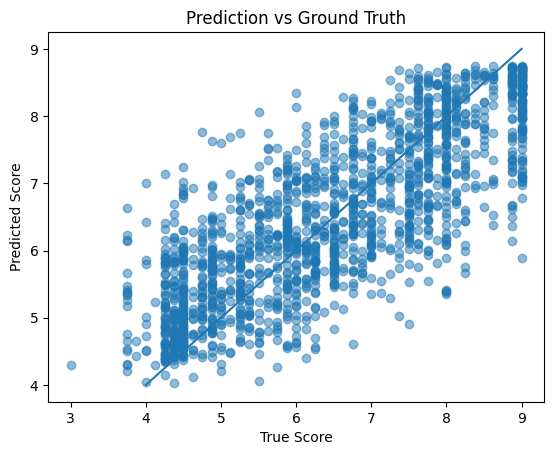

In [24]:
plt.scatter(true_overall, pred_overall, alpha=0.5)
plt.plot([4,9], [4,9])  

plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("Prediction vs Ground Truth")
plt.show()

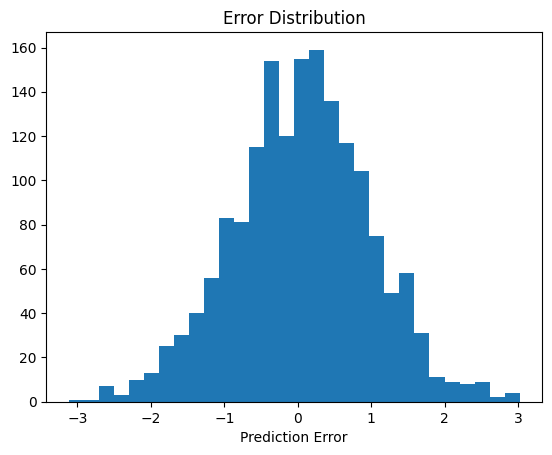

In [25]:
errors = pred_overall - true_overall

plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.show()